# 3D motor visualization and animation (PyVista)

The SPEC's `viz/pyvista_3d.py` slot: the parametric motor rendered as a true
3D assembly — rotor back iron, alternating N/S magnets, slotted stator with
copper coils, and yoke — plus two animations:

1. the rotor **spinning** over a cutaway stator;
2. an **exploded view** that separates and reassembles the stack.

Requires `pip install "axfluxmdo[viz3d]"` (PyVista/VTK). Mesh construction
works everywhere; rendering needs a GL context (the committed GIFs in
`docs/images/` are the reference output).

In [1]:
from pathlib import Path

from axfluxmdo import AxialFluxMotor
from axfluxmdo.viz import build_motor_assembly

HERE = Path(__file__).parent if "__file__" in globals() else Path(".")
OUTPUT_DIR = HERE / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)

## Trust the mesh: component volumes vs the analytical properties

Every solid is built from the same `AxialFluxMotor` dimensions the physics
models use, so the mesh volumes must reproduce the motor's analytic volume
properties.

In [2]:
assembly = build_motor_assembly(motor, theta_cutaway_deg=None)
checks = [
    ("rotor iron", assembly["rotor_iron"].volume, motor.back_iron_volume),
    ("magnets (28)", sum(b.volume for b in assembly["magnets"]), motor.magnet_volume),
    ("stator yoke", assembly["stator_yoke"].volume, motor.stator_core_volume),
]
for name, mesh_v, motor_v in checks:
    print(
        f"{name:14s} mesh {mesh_v * 1e6:8.2f} cm³ vs analytic {motor_v * 1e6:8.2f} cm³ "
        f"({mesh_v / motor_v - 1:+.2%})"
    )

rotor iron     mesh   108.81 cm³ vs analytic   108.86 cm³ (-0.05%)
magnets (28)   mesh    61.66 cm³ vs analytic    61.69 cm³ (-0.04%)
stator yoke    mesh   145.08 cm³ vs analytic   145.14 cm³ (-0.05%)


## Static cutaway view

In [3]:
from axfluxmdo.viz.pyvista_3d import _can_render  # noqa: E402

if _can_render():
    from axfluxmdo.viz import plot_motor_3d

    plotter = plot_motor_3d(motor, screenshot=OUTPUT_DIR / "08_motor_3d.png")
    plotter.close()
    print("wrote", OUTPUT_DIR / "08_motor_3d.png")
else:
    print("no GL context here — see the committed renders in docs/images/")

wrote output/08_motor_3d.png


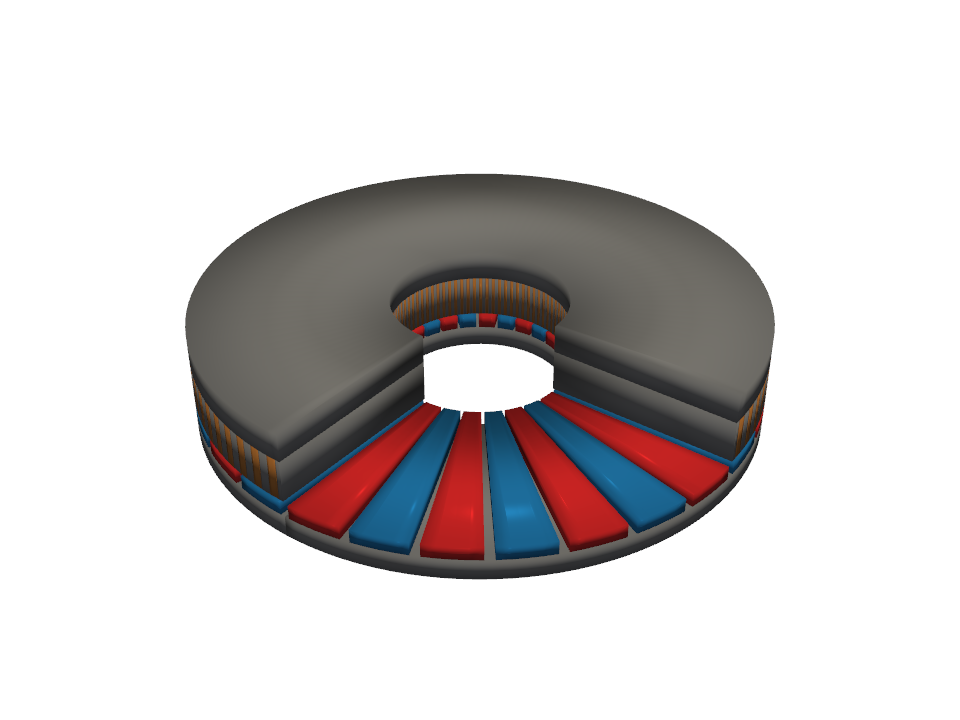

In [4]:
if (OUTPUT_DIR / "08_motor_3d.png").exists():
    from IPython.display import Image, display

    display(Image(str(OUTPUT_DIR / "08_motor_3d.png"), width=640))

## Spinning rotor

One full mechanical revolution; only the rotor-side meshes rotate. At
p = 14 a 72-frame revolution is 5°/frame against a 12.9° pole pitch.

In [5]:
if _can_render():
    from axfluxmdo.viz import animate_rotation

    gif = animate_rotation(motor, OUTPUT_DIR / "08_rotation.gif")
    print(f"wrote {gif} ({gif.stat().st_size / 1e6:.1f} MB)")

wrote /Users/johnhodge/Documents/code/axfluxmdo/examples/output/08_rotation.gif (2.3 MB)


## Exploded assembly

Components translate apart axially (ease-in-out), hold, and reassemble —
rotor iron and magnets downward, coils/teeth and yoke upward, offsets
proportional to their position in the stack.

In [6]:
if _can_render():
    from axfluxmdo.viz import animate_exploded

    gif = animate_exploded(motor, OUTPUT_DIR / "08_exploded.gif")
    print(f"wrote {gif} ({gif.stat().st_size / 1e6:.1f} MB)")

wrote /Users/johnhodge/Documents/code/axfluxmdo/examples/output/08_exploded.gif (3.9 MB)
